# The goal - to find which CSS attributes are correlated with each other.

Those that are correlated can be used to reduce the number of attributes in the fingerprint, because they provide similar information. This analysis can help in reducing the size of the fingerprint and improving its performance.

In [49]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [50]:
df = pd.read_parquet('2_after_feature_extraction/feature_matrix_media_calc.parquet')

In [51]:
css_cols = [
    col for col in df.columns
    if col.startswith('css:')
    and (not col == 'css:font_vector')
    and col != 'css:User-Agent'
]

df_css = df[css_cols].copy()

In [52]:
df_css

,css:calc-10-width,css:calc-2-width,css:calc-3-width,css:calc-4-width,css:calc-5-width,css:calc-6-width,css:calc-7-width,css:calc-8-width,css:calc-9-width,css:env-1-height,...,css:font_marlett,css:font_meiryo_ui,css:font_menlo,css:font_microsoft_uighur,css:font_ms_mincho,css:font_ms_ui_gothic,css:font_sans-serif-thin,css:font_segoe_ui_light,css:font_simhei,css:font_vrinda
0,0.239583,7.937500,279.102000,6.496094,0.604167,938.685000,19.601600,139.102000,0.207031,136,...,0,0,1,0,0,0,0,0,0,0
1,0.239583,7.937500,279.102000,6.496094,0.604167,938.685000,19.601600,139.102000,0.207031,136,...,0,0,1,0,0,0,0,0,0,0
2,0.239583,7.937500,279.102000,6.496094,0.604167,938.685000,19.601600,139.102000,0.207031,136,...,0,0,1,0,0,0,0,0,0,0
3,50.033300,0.000000,94.483300,3.183330,0.000000,2107.983398,16.500000,0.000000,0.000000,136,...,1,1,0,1,1,1,0,1,1,1
4,5.602941,7.953125,274.921875,6.496094,0.370536,938.622253,19.651787,59.558338,0.327381,130,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,5.602941,7.953125,274.924133,6.496094,0.370536,938.622253,19.651787,59.558338,0.327381,136,...,0,0,1,0,0,0,0,0,0,0
918,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,136,...,0,0,1,0,0,0,0,0,0,0
919,5.602941,7.953125,274.924133,6.496094,0.370536,938.622253,19.651787,59.558338,0.327381,136,...,0,0,1,0,0,0,0,0,0,0
920,0.239583,7.937500,279.102000,6.496094,0.604167,938.685000,19.601600,139.102000,0.207031,136,...,1,0,0,0,0,1,0,1,0,0


In [53]:
# some rows have NaN values, which will cause issues with correlation matrix (espacially the image-set-href attribute)
df_css = df_css.replace(r'^\s*$', np.nan, regex=True)

In [54]:
corr_matrix = df_css.corr(method='pearson')

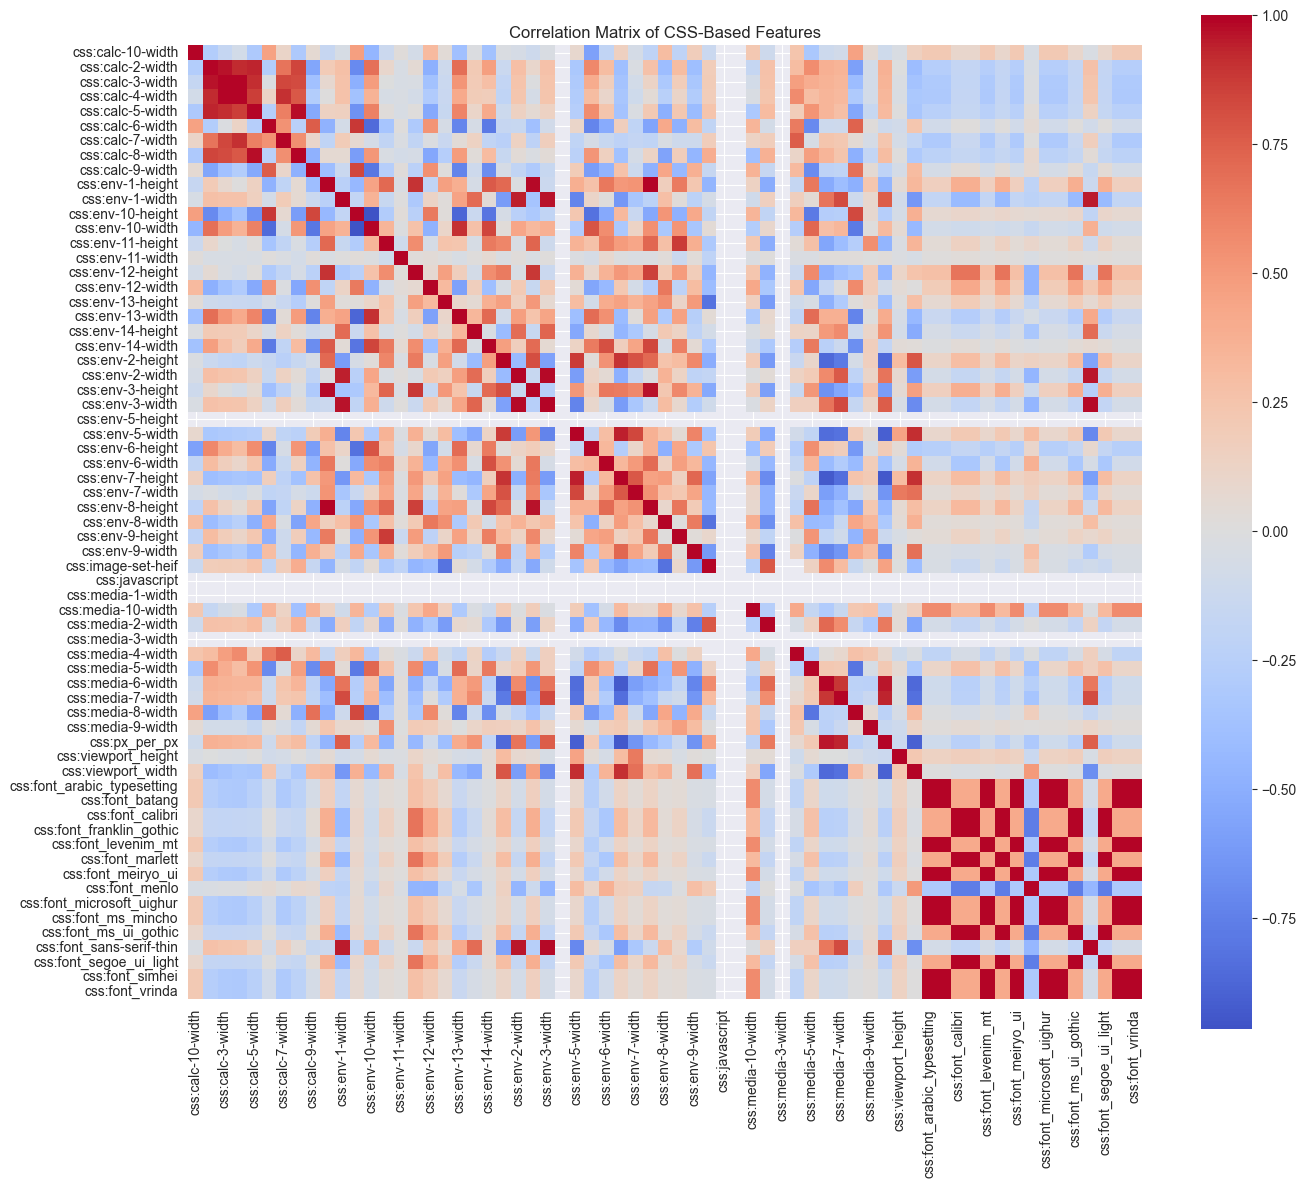

In [55]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt=".2f", square=True)
plt.title("Correlation Matrix of CSS-Based Features")
plt.tight_layout()
plt.show()

In [56]:
threshold = 0.85  # High correlation threshold
high_corr = []

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if row != col and abs(corr_matrix.loc[row, col]) > threshold:
            pair = tuple(sorted((row, col)))
            if pair not in high_corr:
                high_corr.append(pair)

print(f"\\nHighly correlated CSS feature pairs (|r| > {threshold}):")
for a, b in sorted(high_corr):
    print(f"- {a} <--> {b} (r = {corr_matrix.loc[a, b]:.2f})")

\nHighly correlated CSS feature pairs (|r| > 0.85):
- css:calc-2-width <--> css:calc-3-width (r = 0.97)
- css:calc-2-width <--> css:calc-4-width (r = 0.92)
- css:calc-2-width <--> css:calc-5-width (r = 0.94)
- css:calc-3-width <--> css:calc-4-width (r = 0.99)
- css:calc-3-width <--> css:calc-5-width (r = 0.91)
- css:calc-4-width <--> css:calc-5-width (r = 0.86)
- css:calc-4-width <--> css:calc-7-width (r = 0.90)
- css:calc-5-width <--> css:calc-8-width (r = 0.97)
- css:calc-6-width <--> css:env-10-height (r = 0.88)
- css:calc-6-width <--> css:env-10-width (r = -0.85)
- css:env-1-height <--> css:env-12-height (r = 0.89)
- css:env-1-height <--> css:env-3-height (r = 0.98)
- css:env-1-height <--> css:env-8-height (r = 0.99)
- css:env-1-width <--> css:env-2-width (r = 0.94)
- css:env-1-width <--> css:env-3-width (r = 0.97)
- css:env-1-width <--> css:font_sans-serif-thin (r = 0.95)
- css:env-10-height <--> css:env-10-width (r = -0.97)
- css:env-10-height <--> css:env-13-width (r = -0.88)
- 

In [57]:
# DEBUG: find rows with empty strings
# mask = df.applymap(lambda x: isinstance(x, str) and x.strip() == '')
# df[mask.any(axis=1)]